In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder



In [2]:
dry_bean = fetch_openml(data_id=44225, as_frame=True)

X = dry_bean.data
y = dry_bean.target

# Create dataframe
bean_df = X.copy()
bean_df["Class"] = y

In [3]:
print("Columns:\n", bean_df.columns)
print("\nFirst 5 rows:\n", bean_df.head())


Columns:
 Index(['MEMBERSHIP_NUMBER', 'MEMBERSHIP_TERM_YEARS', 'ANNUAL_FEES',
       'MEMBER_MARITAL_STATUS', 'MEMBER_GENDER', 'MEMBER_ANNUAL_INCOME',
       'MEMBER_OCCUPATION_CD', 'MEMBERSHIP_PACKAGE', 'MEMBER_AGE_AT_ISSUE',
       'ADDITIONAL_MEMBERS', 'PAYMENT_MODE', 'AGENT_CODE',
       'START_DATE (YYYYMMDD)', 'END_DATE  (YYYYMMDD)', 'Class'],
      dtype='str')

First 5 rows:
   MEMBERSHIP_NUMBER  MEMBERSHIP_TERM_YEARS  ANNUAL_FEES MEMBER_MARITAL_STATUS  \
0            A00001                     29     113125.0                     M   
1            A00002                     38     112220.0                     M   
2            A00003                     12     100000.0                     M   
3            A00004                     12     100000.0                     M   
4            A00005                     46     100000.0                     M   

  MEMBER_GENDER  MEMBER_ANNUAL_INCOME  MEMBER_OCCUPATION_CD  \
0             M            25200000.0                   1.0   


In [4]:
#combine into one datframe for easy analysis 
df = X.copy()
df["Class"] = y


In [5]:
# Check columns
print(df.columns)

# Shape
print("Dataset Shape:", df.shape)

# Class distribution
print(df["Class"].value_counts())


Index(['MEMBERSHIP_NUMBER', 'MEMBERSHIP_TERM_YEARS', 'ANNUAL_FEES',
       'MEMBER_MARITAL_STATUS', 'MEMBER_GENDER', 'MEMBER_ANNUAL_INCOME',
       'MEMBER_OCCUPATION_CD', 'MEMBERSHIP_PACKAGE', 'MEMBER_AGE_AT_ISSUE',
       'ADDITIONAL_MEMBERS', 'PAYMENT_MODE', 'AGENT_CODE',
       'START_DATE (YYYYMMDD)', 'END_DATE  (YYYYMMDD)', 'Class'],
      dtype='str')
Dataset Shape: (10362, 15)
Class
INFORCE      7219
CANCELLED    3143
Name: count, dtype: int64


In [6]:
df

,MEMBERSHIP_NUMBER,MEMBERSHIP_TERM_YEARS,ANNUAL_FEES,MEMBER_MARITAL_STATUS,MEMBER_GENDER,MEMBER_ANNUAL_INCOME,MEMBER_OCCUPATION_CD,MEMBERSHIP_PACKAGE,MEMBER_AGE_AT_ISSUE,ADDITIONAL_MEMBERS,PAYMENT_MODE,AGENT_CODE,START_DATE (YYYYMMDD),END_DATE (YYYYMMDD),Class
0,A00001,29,113125.00,M,M,25200000.0,1.0,TYPE-B,45,2,ANNUAL,477,20060914,NaN,INFORCE
1,A00002,38,112220.00,M,M,10339200.0,1.0,TYPE-B,36,3,QUARTERLY,255,20061102,NaN,INFORCE
2,A00003,12,100000.00,M,M,14400000.0,1.0,TYPE-B,42,1,ANNUAL,7866,20070124,NaN,INFORCE
3,A00004,12,100000.00,M,M,9000000.0,1.0,TYPE-B,39,2,ANNUAL,200533,20070122,NaN,INFORCE
4,A00005,46,100000.00,M,M,4800000.0,1.0,TYPE-B,27,2,QUARTERLY,6988,20070131,NaN,INFORCE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10357,A10362,17,206180.15,NaN,M,NaN,6.0,TYPE-A,71,0,ANNUAL,1438477,20131129,NaN,INFORCE
10358,A10363,22,100000.42,NaN,F,399996.0,2.0,TYPE-A,63,0,ANNUAL,1288288,20131129,NaN,INFORCE
10359,A10364,17,270950.45,NaN,M,NaN,6.0,TYPE-A,62,3,ANNUAL,1244022,20131129,NaN,INFORCE
10360,A10365,57,210006.61,NaN,M,NaN,6.0,TYPE-A,72,2,ANNUAL,1436000,20131129,NaN,INFORCE


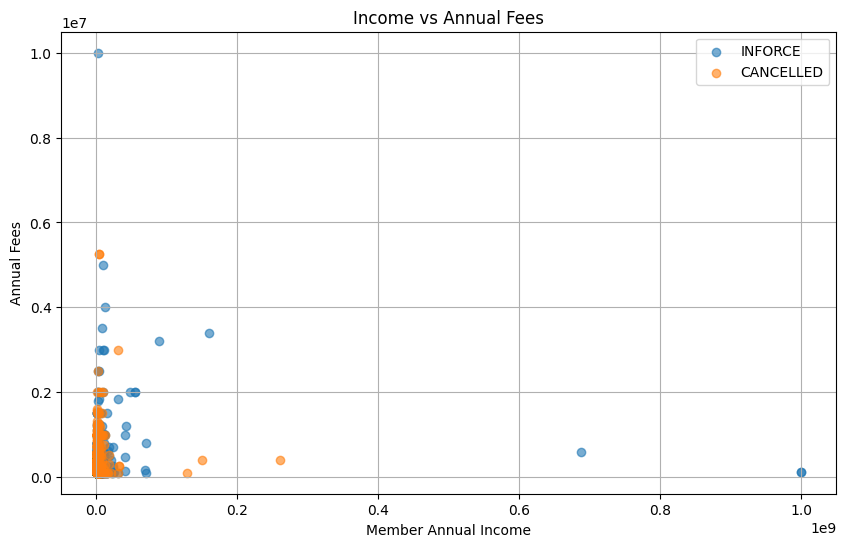

In [7]:
# visualize relationship between area and parameter 
plt.figure(figsize=(10, 6))

classes = df["Class"].unique()

for bean_class in classes:
    subset = df[df["Class"] == bean_class]
    plt.scatter(
        subset["MEMBER_ANNUAL_INCOME"], 
        subset["ANNUAL_FEES"], 
        label=bean_class, 
        alpha=0.6
    )

plt.title("Income vs Annual Fees")
plt.xlabel("Member Annual Income")
plt.ylabel("Annual Fees")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

MEMBERSHIP_NUMBER           0
MEMBERSHIP_TERM_YEARS       0
ANNUAL_FEES                 0
MEMBER_MARITAL_STATUS    2597
MEMBER_GENDER             611
MEMBER_ANNUAL_INCOME     1754
MEMBER_OCCUPATION_CD       43
MEMBERSHIP_PACKAGE          0
MEMBER_AGE_AT_ISSUE         0
ADDITIONAL_MEMBERS          0
PAYMENT_MODE                0
AGENT_CODE                  0
START_DATE (YYYYMMDD)       0
END_DATE  (YYYYMMDD)     7219
Class                       0
dtype: int64


In [9]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

In [10]:
for col in df.columns:
    
    # If column is numeric
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    
    # If column is categorical (string)
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
# Check again
print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())




Missing Values After Cleaning:

MEMBERSHIP_NUMBER        0
MEMBERSHIP_TERM_YEARS    0
ANNUAL_FEES              0
MEMBER_MARITAL_STATUS    0
MEMBER_GENDER            0
MEMBER_ANNUAL_INCOME     0
MEMBER_OCCUPATION_CD     0
MEMBERSHIP_PACKAGE       0
MEMBER_AGE_AT_ISSUE      0
ADDITIONAL_MEMBERS       0
PAYMENT_MODE             0
AGENT_CODE               0
START_DATE (YYYYMMDD)    0
END_DATE  (YYYYMMDD)     0
Class                    0
dtype: int64


In [12]:
# Convert date columns
if "START_DATE (YYYYMMDD)" in df.columns:
    df["START_DATE (YYYYMMDD)"] = pd.to_datetime(
        df["START_DATE (YYYYMMDD)"], errors="coerce"
    )

if "END_DATE  (YYYYMMDD)" in df.columns:
    df["END_DATE  (YYYYMMDD)"] = pd.to_datetime(
        df["END_DATE  (YYYYMMDD)"], errors="coerce"
    )


In [13]:
# Final check
print("\nData Types:\n")
print(df.dtypes)


Data Types:

MEMBERSHIP_NUMBER                   str
MEMBERSHIP_TERM_YEARS             int64
ANNUAL_FEES                     float64
MEMBER_MARITAL_STATUS               str
MEMBER_GENDER                       str
MEMBER_ANNUAL_INCOME            float64
MEMBER_OCCUPATION_CD            float64
MEMBERSHIP_PACKAGE                  str
MEMBER_AGE_AT_ISSUE               int64
ADDITIONAL_MEMBERS                int64
PAYMENT_MODE                        str
AGENT_CODE                          str
START_DATE (YYYYMMDD)    datetime64[ns]
END_DATE  (YYYYMMDD)     datetime64[ns]
Class                               str
dtype: object


In [14]:
df_model = df.copy()

# Convert datetime columns into numeric year/month/day features
df_model["START_YEAR"] = df_model["START_DATE (YYYYMMDD)"].dt.year
df_model["START_MONTH"] = df_model["START_DATE (YYYYMMDD)"].dt.month
df_model["START_DAY"] = df_model["START_DATE (YYYYMMDD)"].dt.day

df_model["END_YEAR"] = df_model["END_DATE  (YYYYMMDD)"].dt.year
df_model["END_MONTH"] = df_model["END_DATE  (YYYYMMDD)"].dt.month
df_model["END_DAY"] = df_model["END_DATE  (YYYYMMDD)"].dt.day

# Drop original date columns and ID-like columns
X = df_model.drop(columns=[
    "Class",
    "MEMBERSHIP_NUMBER",
    "AGENT_CODE",
    "START_DATE (YYYYMMDD)",
    "END_DATE  (YYYYMMDD)"
], errors="ignore")

y = df_model["Class"]

# Convert categorical columns into numeric
X = pd.get_dummies(X, drop_first=True)

# Encode target column
le = LabelEncoder()
y = le.fit_transform(y)


In [15]:
#Model Building
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [16]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    bootstrap=True,
    oob_score=True,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# OOB Score
print("OOB Score:", rf_model.oob_score_)


OOB Score: 0.6967064784654361


In [17]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)


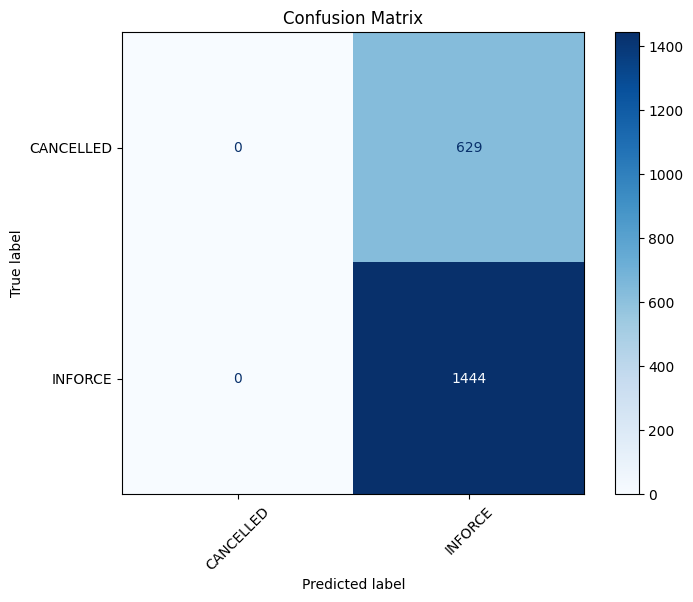

In [18]:

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

In [19]:

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:

              precision    recall  f1-score   support

   CANCELLED       0.00      0.00      0.00       629
     INFORCE       0.70      1.00      0.82      1444

    accuracy                           0.70      2073
   macro avg       0.35      0.50      0.41      2073
weighted avg       0.49      0.70      0.57      2073



c:\Users\HP\OneDrive\Desktop\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\OneDrive\Desktop\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\OneDrive\Desktop\ML\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [20]:

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

top5 = feature_importances.sort_values(ascending=False).head(5)

print("\nTop 5 Important Features:\n")
print(top5)


Top 5 Important Features:

MEMBERSHIP_PACKAGE_TYPE-B    0.341853
MEMBERSHIP_TERM_YEARS        0.250058
ANNUAL_FEES                  0.097175
MEMBER_AGE_AT_ISSUE          0.090853
MEMBER_ANNUAL_INCOME         0.085525
dtype: float64


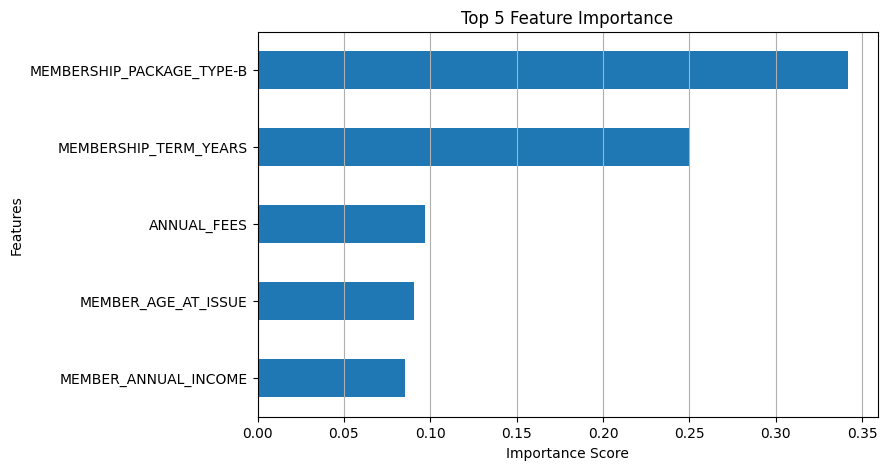

In [21]:
plt.figure(figsize=(8, 5))
top5.sort_values().plot(kind="barh")

plt.title("Top 5 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis="x")

plt.show()